In [191]:
from pathlib import Path

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

output_file = (
        Path("..") / ".."/ "results" / "megadata" / "intensive_extensive_summary.csv"
)

summary_df = pd.read_csv(output_file, header = 0)


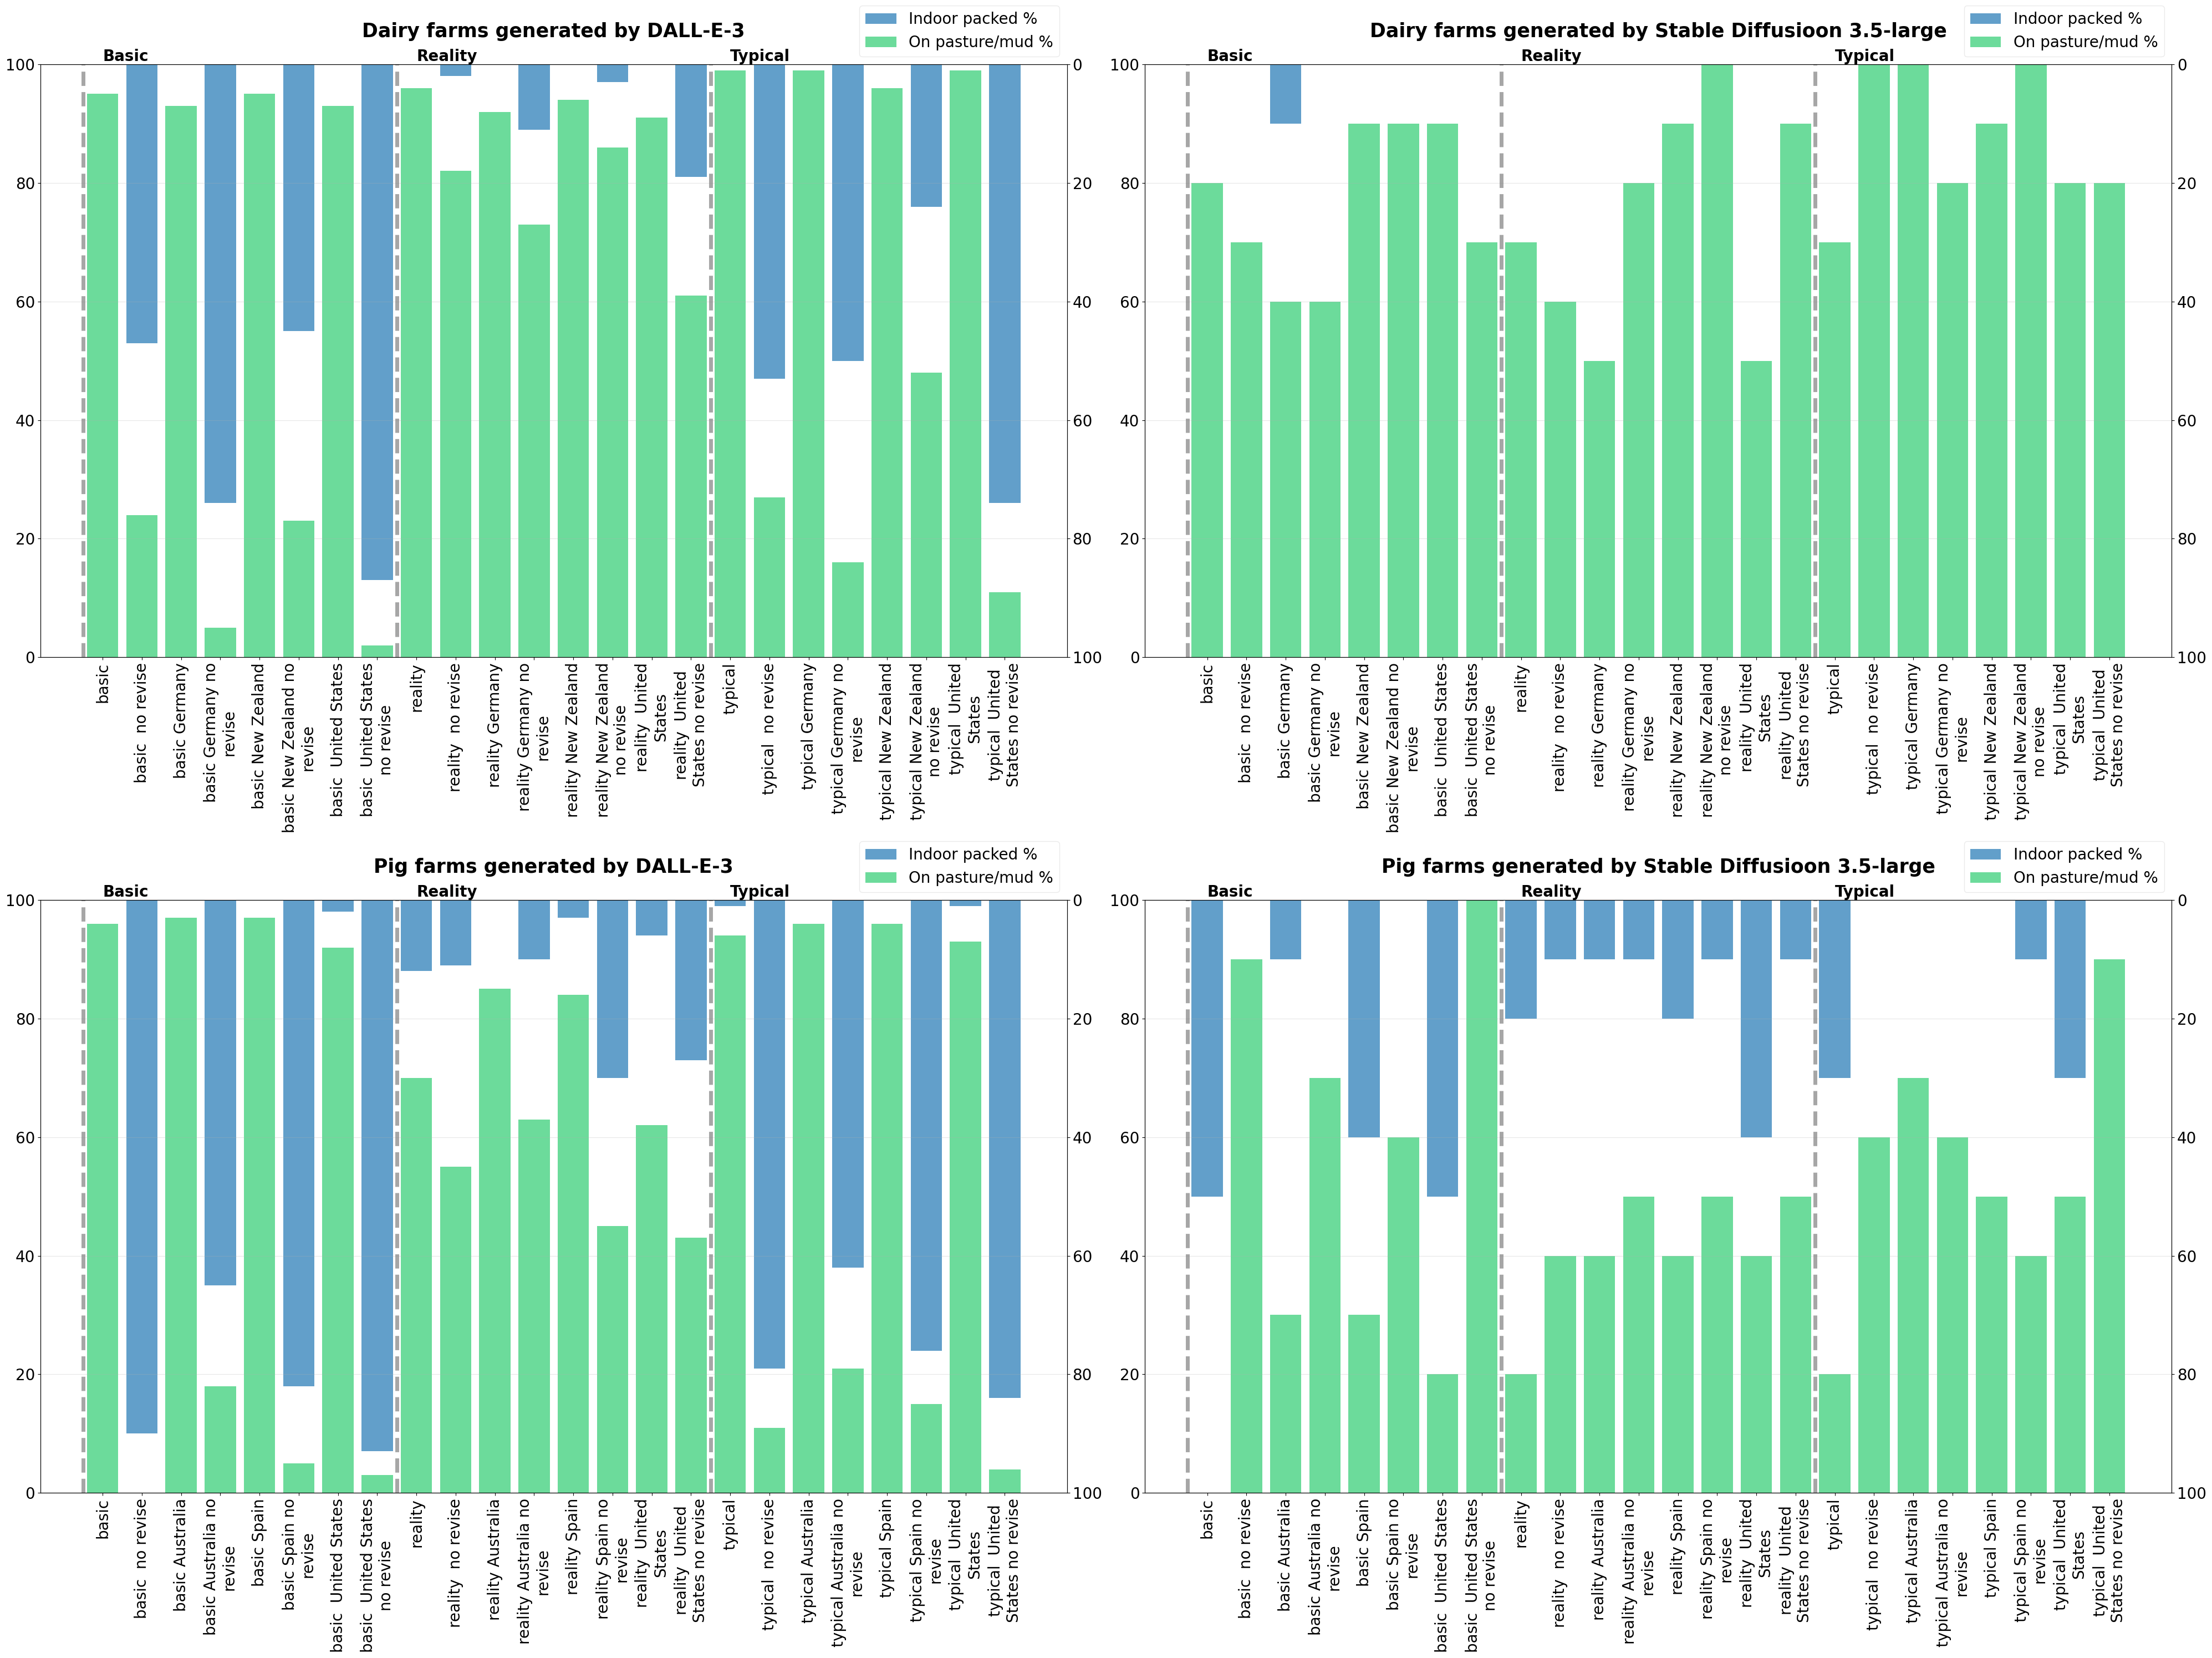

In [218]:

# Function to group generation types
def get_group(gen_type):
    word_list = gen_type.split("_")
    word1 = word_list[0]
    group_name_major = word1
    group_name_minor = word1
    if (len(word_list) > 1):
        word2 = word_list[1]
        
        if (word2 == "country"):
            group_name_minor = word1 + " " + word2
        
    return group_name_major, group_name_minor

def wrap_labels(text, width=20):
    """Wrap text at specified width using textwrap."""
    import textwrap
    return textwrap.fill(text, width=width, break_long_words=False)

def create_plot_grid(summary_df):
    """
    Create a 2x2 grid of plots showing intensive and extensive percentages for different farm types and models.
    
    Parameters
    ----------
    summary_df : pandas.DataFrame
        DataFrame containing columns: generation_type, country, farm_type, model, inten_pct, exten_pct
    
    Returns
    -------
    matplotlib.figure.Figure
        The complete figure containing the plot grid
    """
    
    # Create figure and axes grid
    fig, axes = plt.subplots(2, 2, figsize=(40, 30))
    plt.subplots_adjust(top=0.85,     # top margin
                    bottom=0.3,     # bottom margin
                    left=0.1,       # left margin
                    right=0.9,      # right margin
                    hspace=0.4,     # height space between plots
                    wspace=0.08)     # width space between plots

    summary_df['model'] = summary_df['model'].apply(lambda x: "DALL-E-3" if "dall-e-3" in x else x) 
    summary_df['model'] = summary_df['model'].apply(lambda x: "Stable Diffusioon 3.5-large" if "sd3.5-large" in x else x) 

    # Define models and farm types
    models = summary_df["model"].unique()
    farm_types = summary_df["farm_type"].unique()
    
    # Define colors
    inten_color = '#1f77b4'  # blue
    exten_color = '#2ecc71'  # green
            
    # Process each subplot
    for i, farm_type in enumerate(farm_types):
        for j, model in enumerate(models):
            
            ax = axes[i, j]

            # Filter data for this subplot
            mask = (summary_df['farm_type'] == farm_type) & (summary_df['model'] == model)
            plot_data = summary_df[mask].copy()

            # Add grouping
            plot_data['group'], plot_data['group_minor'] = zip(*plot_data['generation_type'].apply(get_group))
            plot_data['no_revise'] = plot_data['generation_type'].apply(lambda x: " no revise" if "no_revise" in x else "") 
            plot_data['x_axis_label'] = plot_data['group'] + " " + plot_data['country'].fillna('').str.replace('the', '') + plot_data['no_revise']

            # Sort by group and generation_type
            plot_data = plot_data.sort_values(['group', 'group_minor', 'country', 'generation_type'])
            
            # Create bar positions
            x = range(len(plot_data))
            
            
            # Create twin axis for extensive percentages (bottom)
            ax_bottom = ax
            ax_bottom.bar(x, (plot_data['exten_pct'] * 100), color=exten_color, alpha=0.7, label='On pasture/mud %') 
            ax_bottom.set_ylim(0, 100)
            # Remove y-axis label
            ax_bottom.set_ylabel('')
            # Increase tick font size
            ax_bottom.tick_params(axis='y', labelsize=20)

            # Plot intensive percentages (top)
            ax_top = ax_bottom.twinx()
            ax_top.bar(x, -(plot_data['inten_pct'] * 100), color=inten_color, alpha=0.7, label='Indoor packed %')
            ax_top.set_ylim(-100, 0)  
            # Remove y-axis label  
            ax_top.set_ylabel('')
            # Increase tick font size
            ax_top.tick_params(axis='y', labelsize=20)
            # To show 0-100 instead of 0 to -100 on right axis
            ax_top.yaxis.set_major_formatter(lambda x, pos: str(int(abs(x))))
            
            
            # Set titles and labels
            ax_bottom.set_title(f'{farm_type.capitalize()} farms generated by {model}', 
                            pad=35,  # Add padding between title and plot
                            fontsize=25,  # Increase title font size
                            fontweight='bold')
            ax_bottom.set_xticks(x)

            # Wrap and rotate the labels
            wrapped_labels = [wrap_labels(label) for label in plot_data['x_axis_label']]
            ax_bottom.set_xticklabels(wrapped_labels, 
                                rotation=90,  # or use rotation=270 for better readability
                                ha='center',
                                va='top',
                                fontsize=20)

            # Add gridlines
            ax_top.grid(True, alpha=0.3)

            # Add group separators and labels
            prev_group = None
            for idx, group in enumerate(plot_data['group']):
                if group != prev_group:
                    # Make separation line thicker and darker
                    ax_top.axvline(x=idx-0.5, color='gray', linestyle='--', 
                                    linewidth=5, alpha=0.7)
                    
                    # Add more space between title and group label by adjusting y position
                    # and make font bigger
                    ax_top.text(idx, ax_top.get_ylim()[1] * 1.1,  # Multiply by 1.1 to move up
                                group.capitalize(),
                                horizontalalignment='left', 
                                verticalalignment='bottom',
                                fontsize=20,  # Increase font size
                                fontweight='bold')  # Make text bold
                prev_group = group

            # You might need to adjust the top margin to prevent label cutoff
            plt.subplots_adjust(top=0.85)  # Adjust this value as needed

            # Add legend
            lines_top, labels_top = ax_top.get_legend_handles_labels()
            lines_bottom, labels_bottom = ax_bottom.get_legend_handles_labels()
            ax_top.legend(lines_top + lines_bottom, labels_top + labels_bottom,
                        bbox_to_anchor=(1.0, 1.0),  # (x, y) position relative to plot
                        loc='lower right',
                        fontsize=20,
                        frameon=True,
                        framealpha=0.4,
                        title_fontsize=16)
                
    # Adjust layout
    plt.tight_layout()

    return fig


fig = create_plot_grid(summary_df)
#fig

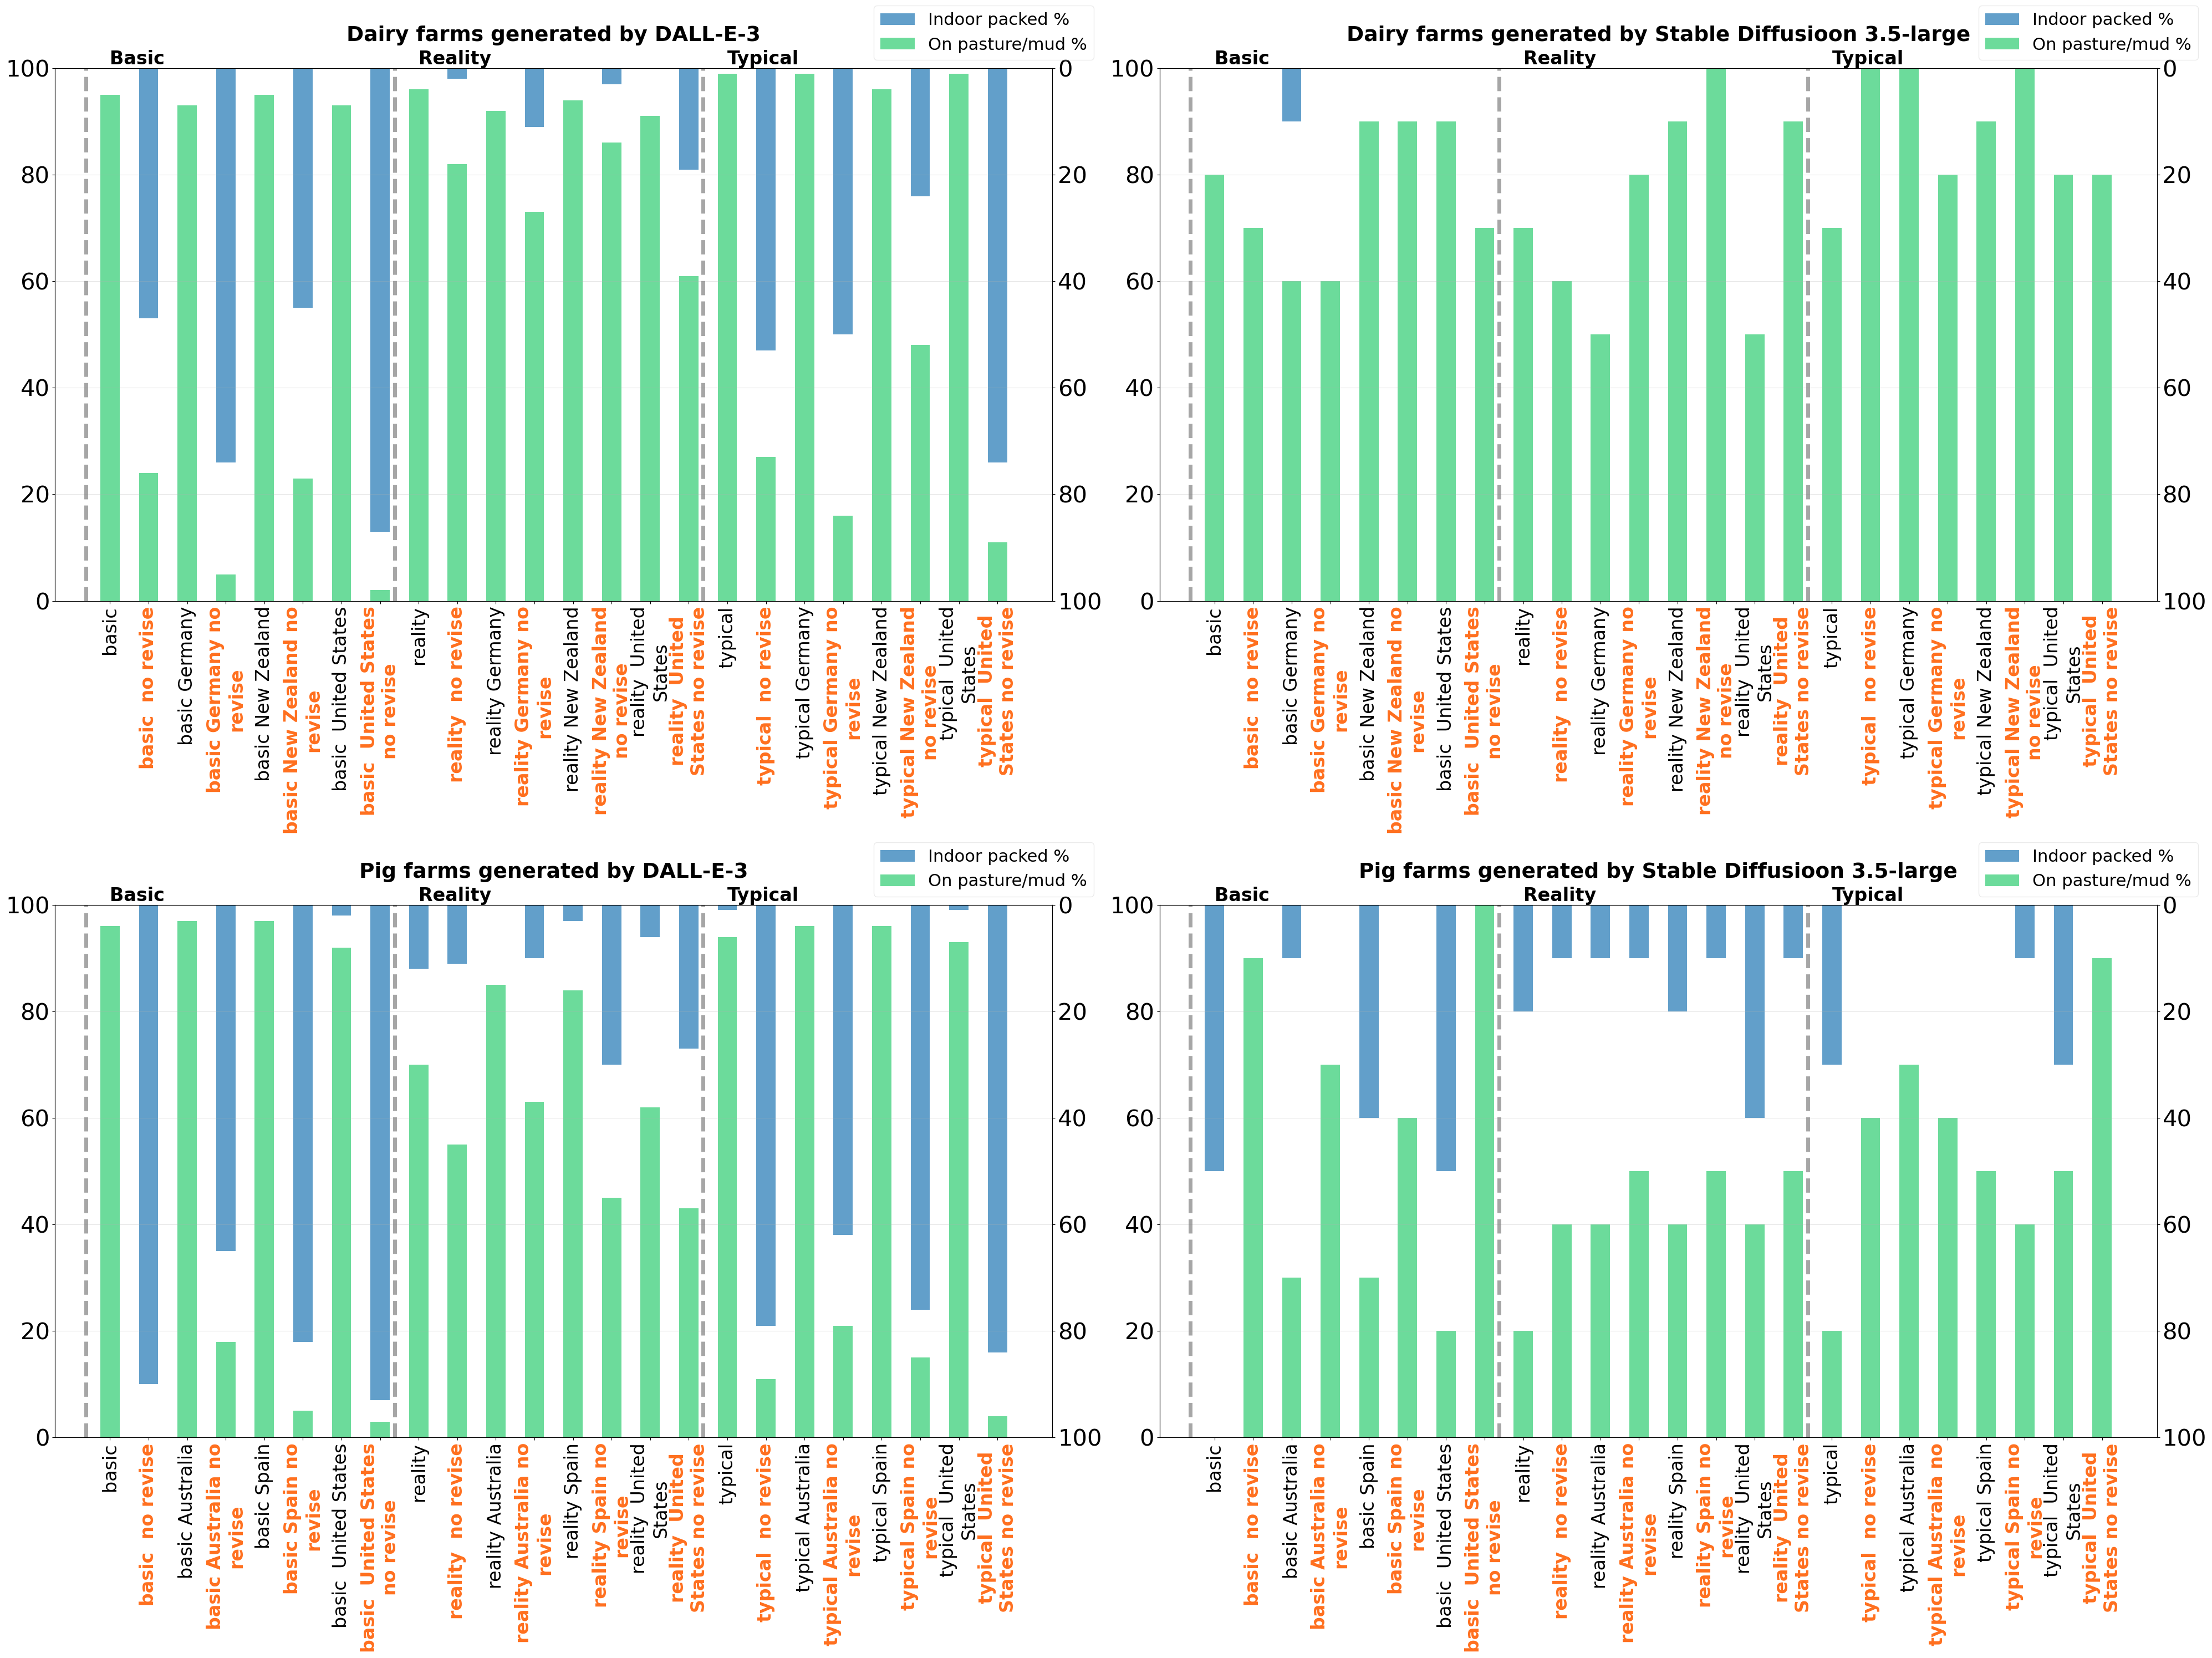

In [231]:
def create_plot_grid(summary_df):
    """
    Create a 2x2 grid of plots showing intensive and extensive percentages for different farm types and models.
    
    Parameters
    ----------
    summary_df : pandas.DataFrame
        DataFrame containing columns: generation_type, country, farm_type, model, inten_pct, exten_pct
    
    Returns
    -------
    matplotlib.figure.Figure
        The complete figure containing the plot grid
    """
    
    # Create figure and axes grid
    fig, axes = plt.subplots(2, 2, figsize=(40, 30))
    plt.subplots_adjust(top=0.9,     # top margin
                    bottom=0.3,     # bottom margin
                    left=0.1,       # left margin
                    right=0.9,      # right margin
                    hspace=0.4,     # height space between plots
                    wspace=0.08)     # width space between plots

    summary_df['model'] = summary_df['model'].apply(lambda x: "DALL-E-3" if "dall-e-3" in x else x) 
    summary_df['model'] = summary_df['model'].apply(lambda x: "Stable Diffusioon 3.5-large" if "sd3.5-large" in x else x) 

    # Define models and farm types
    models = summary_df["model"].unique()
    farm_types = summary_df["farm_type"].unique()
    
    # Define colors
    inten_color = '#1f77b4'  # blue
    exten_color = '#2ecc71'  # green
            
    # Process each subplot
    for i, farm_type in enumerate(farm_types):
        for j, model in enumerate(models):
            
            ax = axes[i, j]

            # Filter data for this subplot
            mask = (summary_df['farm_type'] == farm_type) & (summary_df['model'] == model)
            plot_data = summary_df[mask].copy()

            # Add grouping
            plot_data['group'], plot_data['group_minor'] = zip(*plot_data['generation_type'].apply(get_group))
            plot_data['no_revise'] = plot_data['generation_type'].apply(lambda x: " no revise" if "no_revise" in x else "") 
            plot_data['x_axis_label'] = plot_data['group'] + " " + plot_data['country'].fillna('').str.replace('the', '') + plot_data['no_revise']

            # Sort by group and generation_type
            plot_data = plot_data.sort_values(['group', 'group_minor', 'country', 'generation_type'])
            
            # Create bar positions with increased spacing
            width = 0.6  # Reduced bar width
            x = np.arange(len(plot_data)) * 1.2  # Increased spacing between bars
            
            # Create twin axis for extensive percentages (bottom)
            ax_bottom = ax
            ax_bottom.bar(x, (plot_data['exten_pct'] * 100), width=width, color=exten_color, alpha=0.7, label='On pasture/mud %') 
            ax_bottom.set_ylim(0, 100)
            ax_bottom.set_ylabel('')
            ax_bottom.tick_params(axis='y', labelsize=30)  # Increased tick font size

            # Plot intensive percentages (top)
            ax_top = ax_bottom.twinx()
            ax_top.bar(x, -(plot_data['inten_pct'] * 100), width=width, color=inten_color, alpha=0.7, label='Indoor packed %')
            ax_top.set_ylim(-100, 0)  
            ax_top.set_ylabel('')
            ax_top.tick_params(axis='y', labelsize=30)  # Increased tick font size
            ax_top.yaxis.set_major_formatter(lambda x, pos: str(int(abs(x))))
            
            # Set titles and labels
            ax_bottom.set_title(f'{farm_type.capitalize()} farms generated by {model}', 
                            pad=35,
                            fontsize=27,
                            fontweight='bold')
            ax_bottom.set_xticks(x)

            # Wrap and rotate the labels with conditional formatting
            wrapped_labels = [wrap_labels(label) for label in plot_data['x_axis_label']]
            
            # Create tick labels with different colors and weights based on "no revise"
            tick_labels = []
            tick_colors = []
            tick_weights = []

            for label in plot_data['x_axis_label']:
                wrapped = wrap_labels(label)
                tick_labels.append(wrapped)
                
                if "no revise" in label.lower():
                    tick_colors.append('#FF6F1E')
                    tick_weights.append('bold')
                else:
                    tick_colors.append('black')
                    tick_weights.append('normal')

            ax_bottom.set_xticks(x)
            text_objects = ax_bottom.set_xticklabels(tick_labels,
                                            rotation=90,
                                            ha='center',
                                            va='top',
                                            fontsize=24)

            # Apply colors and font weights to each tick label
            for text_obj, color, weight in zip(text_objects, tick_colors, tick_weights):
                text_obj.set_color(color)
                text_obj.set_fontweight(weight)

            # Add gridlines
            ax_top.grid(True, alpha=0.3)

            # Add group separators and labels
            prev_group = None
            for idx, group in enumerate(plot_data['group']):
                if group != prev_group:
                    ax_top.axvline(x=x[idx]-0.75, color='gray', linestyle='--', 
                                    linewidth=5, alpha=0.7)
                    
                    ax_top.text(x[idx], ax_top.get_ylim()[1] * 1.1,
                                group.capitalize(),
                                horizontalalignment='left', 
                                verticalalignment='bottom',
                                fontsize=24,
                                fontweight='bold')
                prev_group = group

            # Add legend with increased font size
            lines_top, labels_top = ax_top.get_legend_handles_labels()
            lines_bottom, labels_bottom = ax_bottom.get_legend_handles_labels()
            ax_top.legend(lines_top + lines_bottom, labels_top + labels_bottom,
              bbox_to_anchor=(1.05, 1.0),
              loc='lower right',
              fontsize=22,
              frameon=True,
              framealpha=0.4,
              title_fontsize=24)
                
    # Adjust layout
    plt.tight_layout()

    return fig

# Usage
fig = create_plot_grid(summary_df)
